In [3]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Create Exact Folder Structure

import os

base = '/content/drive/MyDrive/advanced_banana_quality_project'

folders = [
    'data/classification/train',
    'data/classification/val',
    'data/classification/test',
    'data/detection/images',
    'data/detection/labels',
    'notebooks',
    'app',
    'models',
    'reports',
    'screenshots'
]

for folder in folders:
    os.makedirs(f'{base}/{folder}', exist_ok=True)
    print(f' Created: {folder}')

print('\n All folders created successfully!')

 Created: data/classification/train
 Created: data/classification/val
 Created: data/classification/test
 Created: data/detection/images
 Created: data/detection/labels
 Created: notebooks
 Created: app
 Created: models
 Created: reports
 Created: screenshots

 All folders created successfully!


In [5]:
# Install & Download Dataset

!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="AWdQF1S7BbXRcYXNFcRM")
project = rf.workspace("roboflow-universe-projects").project("banana-ripeness-classification")
version = project.version(6)
dataset = version.download("folder", location="/content/banana_dataset")

print(" Dataset downloaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.2 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/banana_dataset in folder:: 100%|██████████| 13495/13495 [00:01<00:00, 8084.49it/s]


 Dataset downloaded!


In [6]:
# Check Class Names & Folder Structure

import os

dataset_path = "/content/banana_dataset"

for split in ['train', 'valid', 'test']:
    split_path = f"{dataset_path}/{split}"
    if os.path.exists(split_path):
        classes = os.listdir(split_path)
        print(f"\n {split.upper()} — {len(classes)} classes:")
        for cls in sorted(classes):
            count = len(os.listdir(f"{split_path}/{cls}"))
            print(f"   {cls}: {count} images")


 TRAIN — 4 classes:
   overripe: 2349 images
   ripe: 3522 images
   rotten: 4020 images
   unripe: 1902 images

 VALID — 4 classes:
   overripe: 229 images
   ripe: 339 images
   rotten: 388 images
   unripe: 167 images

 TEST — 4 classes:
   overripe: 113 images
   ripe: 154 images
   rotten: 185 images
   unripe: 110 images


In [7]:
# Copy to Drive Project Folder

import shutil

base = '/content/drive/MyDrive/advanced_banana_quality_project/data/classification'

for split in ['train', 'valid', 'test']:
    src = f"/content/banana_dataset/{split}"
    # rename valid → val
    dst_name = 'val' if split == 'valid' else split
    dst = f"{base}/{dst_name}"

    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f" Copied {split} → {dst_name}")

print("\n Dataset saved to Google Drive!")

 Copied train → train
 Copied valid → val
 Copied test → test

 Dataset saved to Google Drive!


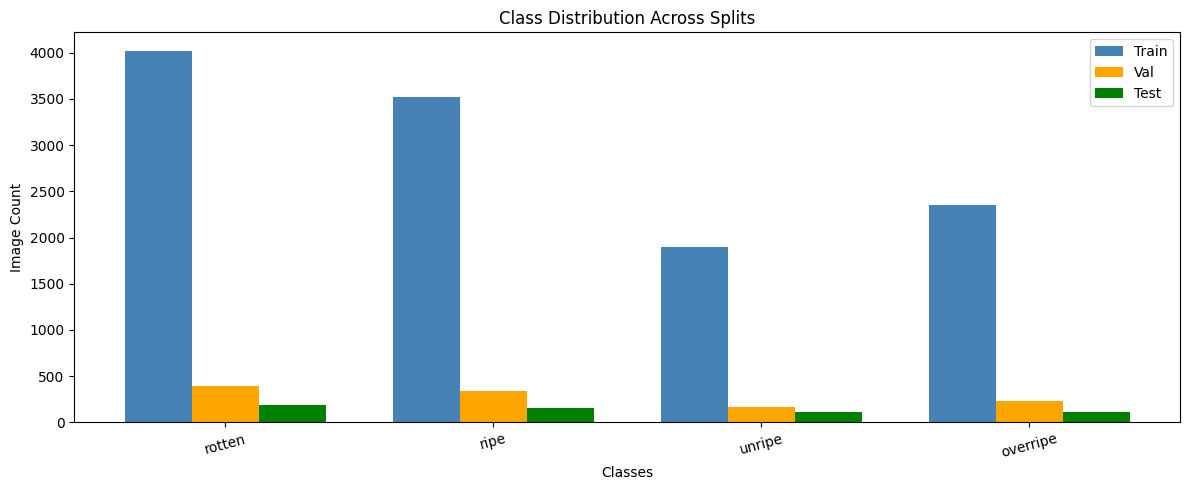

 EDA chart saved!


In [8]:
# EDA (Image counts + Class distribution)

import matplotlib.pyplot as plt
import numpy as np

base_cls = '/content/drive/MyDrive/advanced_banana_quality_project/data/classification'

class_counts = {}

for split in ['train', 'val', 'test']:
    split_path = f"{base_cls}/{split}"
    for cls in os.listdir(split_path):
        cls_path = f"{split_path}/{cls}"
        count = len(os.listdir(cls_path))
        if cls not in class_counts:
            class_counts[cls] = {'train': 0, 'val': 0, 'test': 0}
        class_counts[cls][split] = count

# Plot
classes = list(class_counts.keys())
train_counts = [class_counts[c]['train'] for c in classes]
val_counts = [class_counts[c]['val'] for c in classes]
test_counts = [class_counts[c]['test'] for c in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, train_counts, width, label='Train', color='steelblue')
ax.bar(x, val_counts, width, label='Val', color='orange')
ax.bar(x + width, test_counts, width, label='Test', color='green')

ax.set_xlabel('Classes')
ax.set_ylabel('Image Count')
ax.set_title('Class Distribution Across Splits')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15)
ax.legend()
plt.tight_layout()

# Save screenshot
plt.savefig('/content/drive/MyDrive/advanced_banana_quality_project/screenshots/class_distribution.png')
plt.show()
print(" EDA chart saved!")

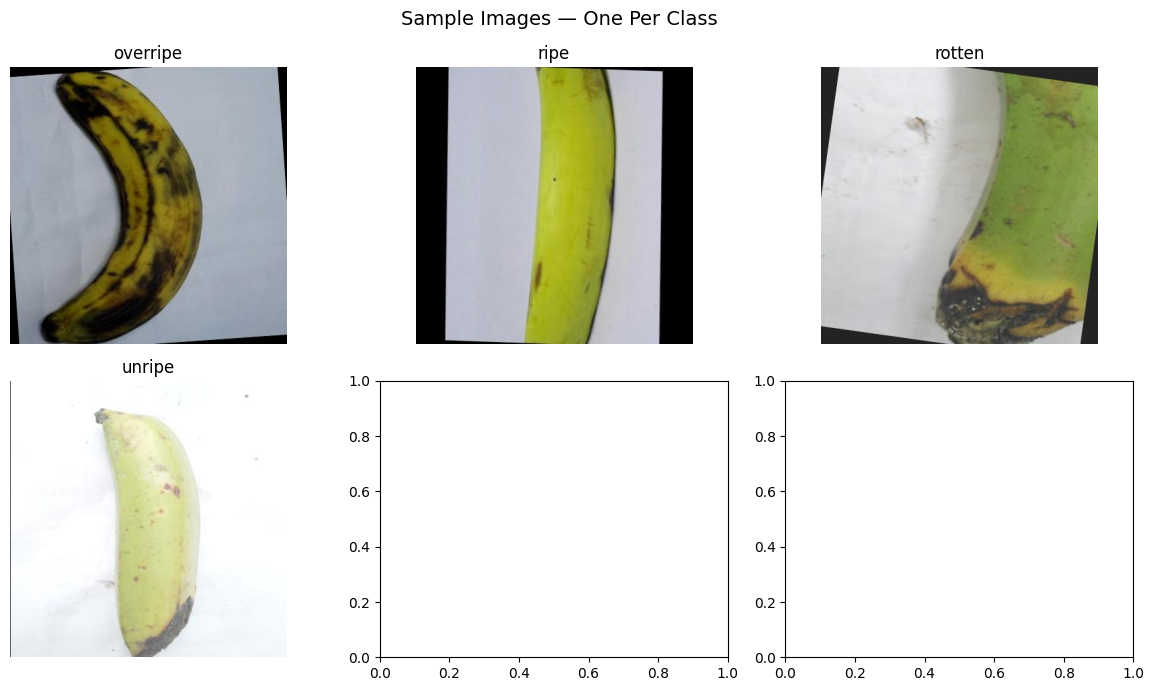

 Sample images saved!


In [9]:
# Sample Images Preview

from PIL import Image
import random

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

base_cls = '/content/drive/MyDrive/advanced_banana_quality_project/data/classification'

for i, cls in enumerate(sorted(class_counts.keys())):
    cls_path = f"{base_cls}/train/{cls}"
    img_file = random.choice(os.listdir(cls_path))
    img = Image.open(f"{cls_path}/{img_file}")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=12)
    axes[i].axis('off')

plt.suptitle('Sample Images — One Per Class', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/advanced_banana_quality_project/screenshots/sample_images.png')
plt.show()
print(" Sample images saved!")

In [10]:
# Data Quality Check

from PIL import Image, UnidentifiedImageError
import os

base_cls = '/content/drive/MyDrive/advanced_banana_quality_project/data/classification'

corrupted = []
total = 0

for split in ['train', 'val', 'test']:
    for cls in os.listdir(f"{base_cls}/{split}"):
        cls_path = f"{base_cls}/{split}/{cls}"
        for img_file in os.listdir(cls_path):
            total += 1
            try:
                img = Image.open(f"{cls_path}/{img_file}")
                img.verify()
            except Exception:
                corrupted.append(f"{split}/{cls}/{img_file}")

print(f" Total images checked: {total}")
print(f" Corrupted images found: {len(corrupted)}")
if corrupted:
    for c in corrupted:
        print(f"   {c}")
else:
    print(" No corrupted images found!")

 Total images checked: 13478
 Corrupted images found: 0
 No corrupted images found!
